# Sota solvers and pruning techniques

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from stochastic_graph import StochasticGraph
from preprocessing import Reach, ArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

%matplotlib inline

%load_ext autoreload
%autoreload 2

## Importing and using the new graph

We use a 5x5 grid network, 25 nodes in total

In [2]:
sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

In [3]:
matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

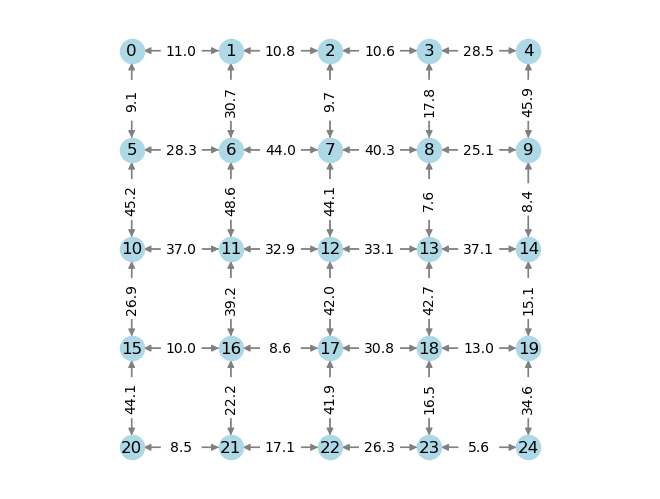

In [5]:
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
graph.print_graph(grid_shape=(5,5))

## Algorithms usage

In [6]:
destination_node = 20
time_budget = 300

### StandardSOTA

In [12]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)

In [13]:
sota = StandardSOTASolver(graph, destination_node, time_budget)
sota.solve();

Convergence reached!
End of iterations


In [14]:
sota.print_sota_matrix()
sota.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  5  5  5]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  7  7]
 ...
 [-1 -1 -1 ... 17 17 17]
 [-1 -1 -1 ... 22 22 22]
 [-1 -1 -1 ... 23 23 23]]


In [15]:
sota.extract_path(3)

[3, 2, 7, 12, 17, 16, 15, 20]

### SingleIteration SOTA

In [24]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
sota2 = SingleIterationSOTASolver(graph, destination_node, time_budget)

In [25]:
sota2.solve()
sota2.print_sota_matrix()
sota2.print_policy_matrix()

SOTA Matrix:
[[  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 ...
 [  0.00   0.00   0.00 ...   0.01   0.01   0.01]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]
 [  0.00   0.00   0.00 ...   0.00   0.00   0.00]]
Policy Matrix:
[[-1 -1 -1 ...  1  5  1]
 [-1 -1 -1 ...  6  6  6]
 [-1 -1 -1 ...  7  1  1]
 ...
 [-1 -1 -1 ... 21 21 21]
 [-1 -1 -1 ... 22 22 22]
 [-1 -1 -1 ... 23 23 23]]


In [26]:
sota2.extract_path(3)

[3, 2, 1, 6, 11, 10, 15, 20]

### Precomputing techniques: Reach

In [33]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)
r = Reach(graph, s)

In [34]:
r.reach_computation()

Loop detected from 3 at time_idx 30
Loop detected from 4 at time_idx 30
Loop detected from 4 at time_idx 49
Loop detected from 7 at time_idx 34
Loop detected from 8 at time_idx 30
Loop detected from 8 at time_idx 34
Loop detected from 9 at time_idx 30
Loop detected from 9 at time_idx 49
Loop detected from 10 at time_idx 34
Loop detected from 11 at time_idx 34
Loop detected from 12 at time_idx 34
Loop detected from 13 at time_idx 30
Loop detected from 13 at time_idx 34
Loop detected from 14 at time_idx 30
Loop detected from 14 at time_idx 34
Loop detected from 15 at time_idx 34
Loop detected from 16 at time_idx 34
Loop detected from 17 at time_idx 34
Loop detected from 18 at time_idx 34
Loop detected from 19 at time_idx 30
Loop detected from 19 at time_idx 34
Loop detected from 20 at time_idx 34
Loop detected from 21 at time_idx 34
Loop detected from 22 at time_idx 34
Loop detected from 23 at time_idx 34
Loop detected from 24 at time_idx 34
Loop detected from 3 at time_idx 30
Loop detec

array([46.76102115, 35.24367885, 39.24831556, 23.70393216, 21.57329159,
       46.76102115, 27.12235177, 23.26233204, 33.56330777, 33.56330777,
       35.66203593, 32.99264464, 48.68270846, 16.91751429, 30.02952189,
       28.04101784, 43.89279631, 48.09876744, 48.31442924, 30.02952189,
       23.6942618 , 35.56020211, 30.27948285, 28.60171258, 20.99341186])

In [35]:
r.reach_pruning()

Pruned nodes: {10, 11, 13, 7}


{7, 10, 11, 13}

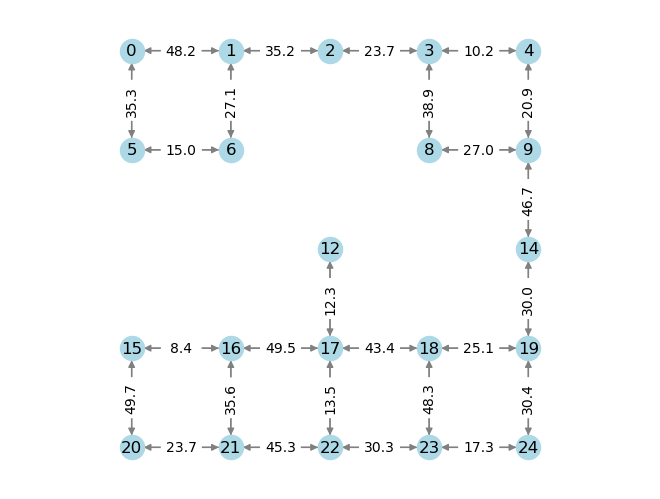

In [36]:
graph.print_graph()

### Precomputing techniques: Arc-flags

In [132]:
adj_matrix, var_matrix = matrix.compute_matrices()
graph = StochasticGraph(adjacency_matrix=adj_matrix, variance_matrix=var_matrix)
s = SingleIterationSOTASolver(graph, destination_node, time_budget)
f = ArcFlags(graph, 4, s)

In [133]:
f.arcflags_computation()


Loop detected from 0 at time_idx 53
Loop detected from 1 at time_idx 53
Loop detected from 2 at time_idx 53
Loop detected from 3 at time_idx 53
Loop detected from 5 at time_idx 53
Loop detected from 6 at time_idx 53
Loop detected from 7 at time_idx 53
Loop detected from 8 at time_idx 53


{(np.int64(0), np.int64(1)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(0), np.int64(5)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(1), np.int64(0)): {0: False, 1: True, 2: False, 3: False},
 (np.int64(1), np.int64(2)): {0: False, 1: True, 2: False, 3: False},
 (np.int64(1), np.int64(6)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(2), np.int64(1)): {0: True, 1: True, 2: False, 3: True},
 (np.int64(2), np.int64(3)): {0: False, 1: True, 2: False, 3: False},
 (np.int64(2), np.int64(7)): {0: False, 1: True, 2: True, 3: True},
 (np.int64(3), np.int64(2)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(3), np.int64(4)): {0: False, 1: True, 2: False, 3: False},
 (np.int64(3), np.int64(8)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(4), np.int64(3)): {0: True, 1: True, 2: False, 3: True},
 (np.int64(4), np.int64(9)): {0: True, 1: True, 2: True, 3: True},
 (np.int64(5), np.int64(0)): {0: False, 1: False, 2: False, 3: False},
 (np.int64(5), np.int64(6)): {0: Tr

In [134]:
f.arcflags_pruning()

[ArcFlags] Pruned 10 edges for destination 20 (region 1).


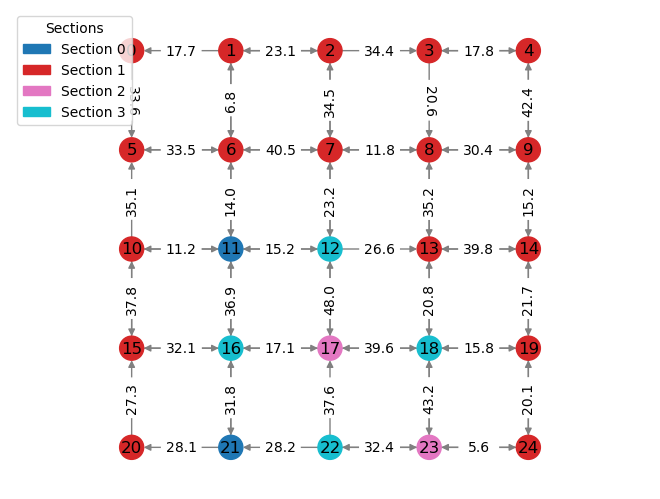

In [135]:
f.print_graph_sections()

In [196]:
import time

standard_sota = StandardSOTASolver(graph, destination_node, time_budget)
singleiteration_sota = SingleIterationSOTASolver(graph, destination_node, time_budget)

# standard SOTA execution
start = time.perf_counter()
standard_sota.solve()
end = time.perf_counter()
print(f"Standard SOTA exec time: {end-start:.6f} seconds")

# singleiteration SOTA execution
start = time.perf_counter()
singleiteration_sota.solve()
end = time.perf_counter()
print(f"Single Iteration SOTA exec time: {end-start:.6f} seconds")

# REACH pruning
# STANDARD
standard_sota = StandardSOTASolver(graph, destination_node, time_budget)
reach_standard = Reach(graph, standard_sota)

# Reach pruning technique execution
start = time.perf_counter()
reach_standard.reach_computation()
reach_standard.reach_pruning()
standard_sota.solve()
end = time.perf_counter()
print(f"Standard Reach pruning exec time: {end-start:.6f} seconds")

# SINGLEITERATION
singleiteration_sota = SingleIterationSOTASolver(graph, destination_node, time_budget)
reach_singleiteration = Reach(graph, singleiteration_sota)
start = time.perf_counter()
reach_singleiteration.reach_computation()
reach_singleiteration.reach_pruning()
singleiteration_sota.solve()
end = time.perf_counter()
print(f"Single iteration Reach exec time: {end-start:.6f} seconds")


KeyboardInterrupt: 